### Imports

In [20]:
from pathlib import Path
import pandas as pd
import warnings

from equity_pricing.calibration import calibrate_smile, calibrate_surface
from equity_pricing.heston import model_surface, price_european
from equity_pricing.plots import plot_residual_heatmap, plot_smile_fit, plot_volatility_surface
from equity_pricing.simulation import price_vanilla_mc
from equity_pricing.types import (
    CalibrationSettings,
    FlatMarketInputs,
    HestonParams,
    OptionSide,
    VanillaOption,
    SmileQuote,
    MarketSmile,
    MarketSurface
)


warnings.filterwarnings('ignore')

### Inputs

We will use the Vol Surface for the S&P 500 Vanilla Call/Puts as of 2023-12-29. The data was retrieved from OptionsDX (https://www.optionsdx.com/product/spx-option-chain/). We pick the implied vols from OTM Call and Put contracts.

The USD risk free rate is retrieved from Fred "Market Yield on U.S. Treasury Securities..." as of 2023-12-29
https://fred.stlouisfed.org/series/DGS10

In [21]:
market = FlatMarketInputs(spot=1.0, risk_free_rate=0.0388, dividend_yield=0.00) # Market date as of 2023-12-29

initial_params = HestonParams(kappa=1.4, theta=0.05, sigma=0.35, rho=-0.15, v0=0.05)

In [22]:
# Reading Implied Vols
path_input=Path().resolve() / Path("input/SPX_IVs_20231229.csv")
data_vols=pd.read_csv(path_input)

In [23]:
# Loading Market Implied Vol Surface

list_smiles=[]
for maturity in set(data_vols["MATURITY"]):
    data_temp=data_vols[data_vols["MATURITY"]==maturity]
    list_quotes=[]

    for _,row in data_temp.iterrows():
        list_quotes.append(SmileQuote(strike=row["STRIKE_REL"],maturity=row["MATURITY"],implied_vol=row["IV_OTM"]))
    
    list_smiles.append(MarketSmile(tuple(list_quotes)))

# Market Surface
market_surface=MarketSurface(tuple(list_smiles)) 

### Run

#### Calibrate Equity Vol Surface

In this block we calibrate the Heston model parameters against: 1) A volatility smile (one tenor) and 2) The volatility surface.

Approach:
- We match the Black-Scholes implied vol surface seen in the market by minimizing the difference in prices across all (strike,maturity) points.
- As a simplified approach, we minimize the difference across all parameters on one-go with least square minimization. A better alternative could be to calibrate first the parameters of the volatility CIR process with ATM VolSwaps/VarSwaps.
- Feller penalty is NOT applied as this could affect the fit to the market vol surface.

In [24]:
# Set limit of calibration settings. Note that we will use multiple starting points (n_restarts=2).
calibration_settings = CalibrationSettings(
    upper_limit=120.0,
    abs_tol=1.0e-7,
    rel_tol=1.0e-7,
    integration_limit=150,
    n_restarts=2,
)


In [25]:
# Surface Calibration results
surface_result = calibrate_surface(
    market_surface,
    market,
    initial_params,
    calibration_settings,
)

# Results report
print(f" Success: {surface_result.success}\n RMSE: {surface_result.rmse}\n MAE: {surface_result.mae}\n MaxAbsError: {surface_result.max_abs_error}" )


 Success: True
 RMSE: 0.0969794992894595
 MAE: 0.0752865574145305
 MaxAbsError: 0.5027862923263875


In [26]:
# Smile calibration results
smile_result = calibrate_smile(
    market_surface.smiles[0],
    market,
    initial_params,
    calibration_settings,
)

# Results report
print(f" Success: {smile_result.success}\n RMSE: {smile_result.rmse}\n MAE: {smile_result.mae}\n MaxAbsError: {smile_result.max_abs_error}" )

 Success: True
 RMSE: 0.11201738274713688
 MAE: 0.07237926536206392
 MaxAbsError: 0.24459301483113224


In [27]:
# Calculating the Vol Surface retrieved from the Heston parameters. This is plotted in another block
model_surface=model_surface(
    tuple([smile.strikes for smile in market_surface.smiles]),
    market_surface.maturities,
    market,
    surface_result.params,
    upper_limit=120.0,
    abs_tol=1.0e-7,
    rel_tol=1.0e-7,
)

#### Price Vanilla Option

Pricing a Vanilla Call Option based on Heston Model. 
- Analytic price: Semi-analytic approach to calculate probabilities, using the Characteristic Function derived from CIR process.
- Simulated price (Monte Carlo): Simulation using antithetic approach to improve MC convergence. The Heston path simulation is based on Andersen QE scheme for the volatility simulation. 

In [28]:
option = VanillaOption(strike=0.85, maturity=1.0, side=OptionSide.CALL)

In [29]:
# Analytic Price with Heston 
analytic_price = price_european(
        option,
        market,
        surface_result.params,
        upper_limit=120.0,
        abs_tol=1.0e-7,
        rel_tol=1.0e-7,
        limit=150,
    )
print(" Analytic price: ",analytic_price)

 Analytic price:  0.1976521246110089


In [30]:
mc_result = price_vanilla_mc(
        option,
        market,
        surface_result.params,
        steps=32,
        n_paths=4_000,
        seed=1234,
    )
print(f" Simulated price (MC): {mc_result.price}\n")

print(f" Results Report\n Standard Error: {mc_result.standard_error}\n Confidence Interval: {mc_result.confidence_interval}")

 Simulated price (MC): 0.2005556775941041

 Results Report
 Standard Error: 0.0039596949348442495
 Confidence Interval: (0.1927948181320437, 0.20831653705616449)


### Plot

#### Plot Vol Smile

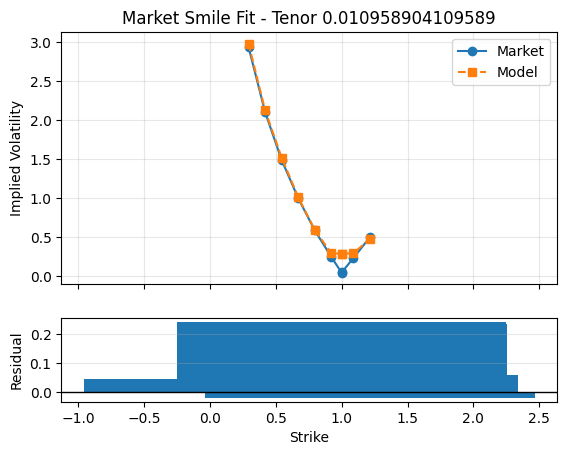

In [31]:
# Plot using smile fit (1 tenor)
smile_figure, _ = plot_smile_fit(
    market_surface.smiles[0],
    smile_result,
    title=f"Market Smile Fit - Tenor {market_surface.maturities[0]}",
)

smile_figure.show()

### Plot Vol Surface

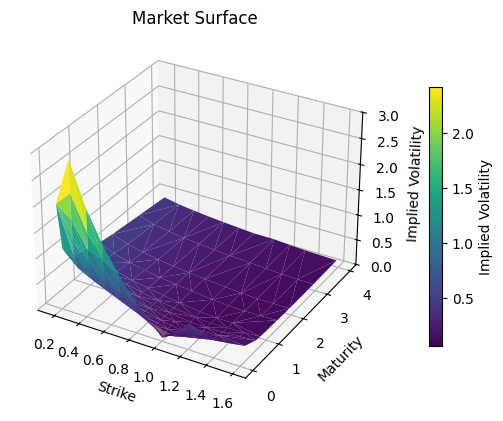

In [32]:
# Plot Market Volatility Surface
surface_mkt_figure, _= plot_volatility_surface(market_surface, title="Market Surface")
surface_mkt_figure.show()

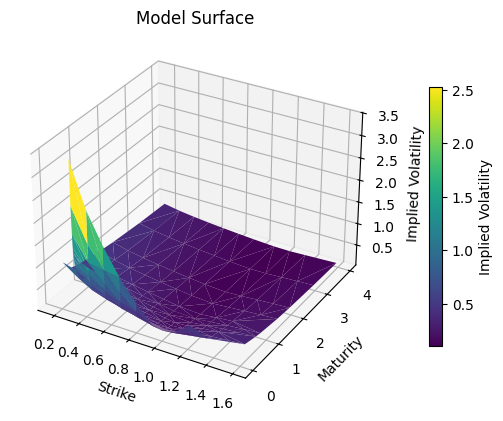

In [33]:
# Plot Model Implied Volatility Surface
surface_mdl_figure, _= plot_volatility_surface(model_surface, title="Model Surface")
surface_mdl_figure.show()

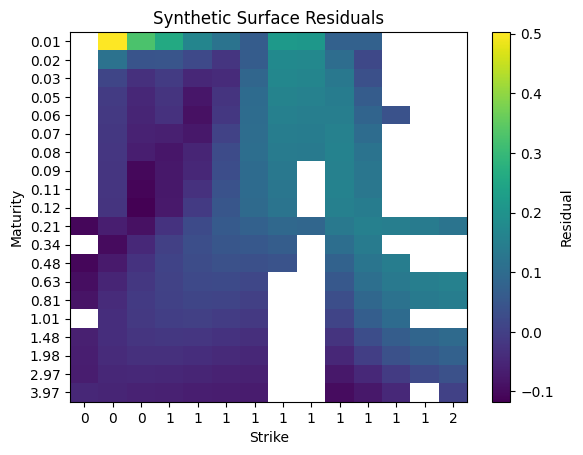

In [34]:
# Heatmap of residuals from Market vol vs Model Vol
heatmap_figure, _ = plot_residual_heatmap(
        market_surface,
        surface_result,
        title="Synthetic Surface Residuals",
    )

heatmap_figure.show()